In [2]:
from sequtils.SomaticVariants import vcf_loader, SmallVariantsFrame
from sequtils.Plots import vaf_histogram, variant_density, depth_distribution
import polars as pl
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import pandas as pd
from pathlib import Path


figure 1

In [5]:
#load as vcf files as Small varinat dataframe
csv_files = sorted(glob.glob("../Julia_SVF/DP3/*.csv"))

loaded_SVF_D3 = {}
for file in csv_files:
    file_title = os.path.splitext(file)[0]
    clean_name = file_title.replace("_julia", "")
    
    loaded_SVF_D3[clean_name] = SmallVariantsFrame.from_csv(file)
    print(f"Loaded: {clean_name}")

print("\nAll data loaded ")

Loaded: ../Julia_SVF/DP3\metastasis_01_DP3
Loaded: ../Julia_SVF/DP3\plasma_01_DP3
Loaded: ../Julia_SVF/DP3\tumor_01_DP3
Loaded: ../Julia_SVF/DP3\tumor_02_DP3
Loaded: ../Julia_SVF/DP3\tumor_03_DP3
Loaded: ../Julia_SVF/DP3\tumor_04_DP3

All data loaded 


In [6]:
#load vcf file as pl df
csv_files = sorted(glob.glob("../Julia_SVF/DP3/*.csv"))

SVF_pl = {}

print("Loading files with Polars...")
for file in csv_files:
    base_name = os.path.splitext(file)[0]
    clean_name = base_name.replace("_julia", "")
    
    df = pl.read_csv(file)
    
    SVF_pl[clean_name] = df.get_column('vaf').to_numpy()
    
    print(f"Loaded: {clean_name} (N = {len(SVF_pl[clean_name])})")

print("\nAll data loaded ")

Loading files with Polars...
Loaded: ../Julia_SVF/DP3\metastasis_01_DP3 (N = 6261317)
Loaded: ../Julia_SVF/DP3\plasma_01_DP3 (N = 1463399)
Loaded: ../Julia_SVF/DP3\tumor_01_DP3 (N = 7107926)
Loaded: ../Julia_SVF/DP3\tumor_02_DP3 (N = 4691488)
Loaded: ../Julia_SVF/DP3\tumor_03_DP3 (N = 4364399)
Loaded: ../Julia_SVF/DP3\tumor_04_DP3 (N = 4482914)

All data loaded 


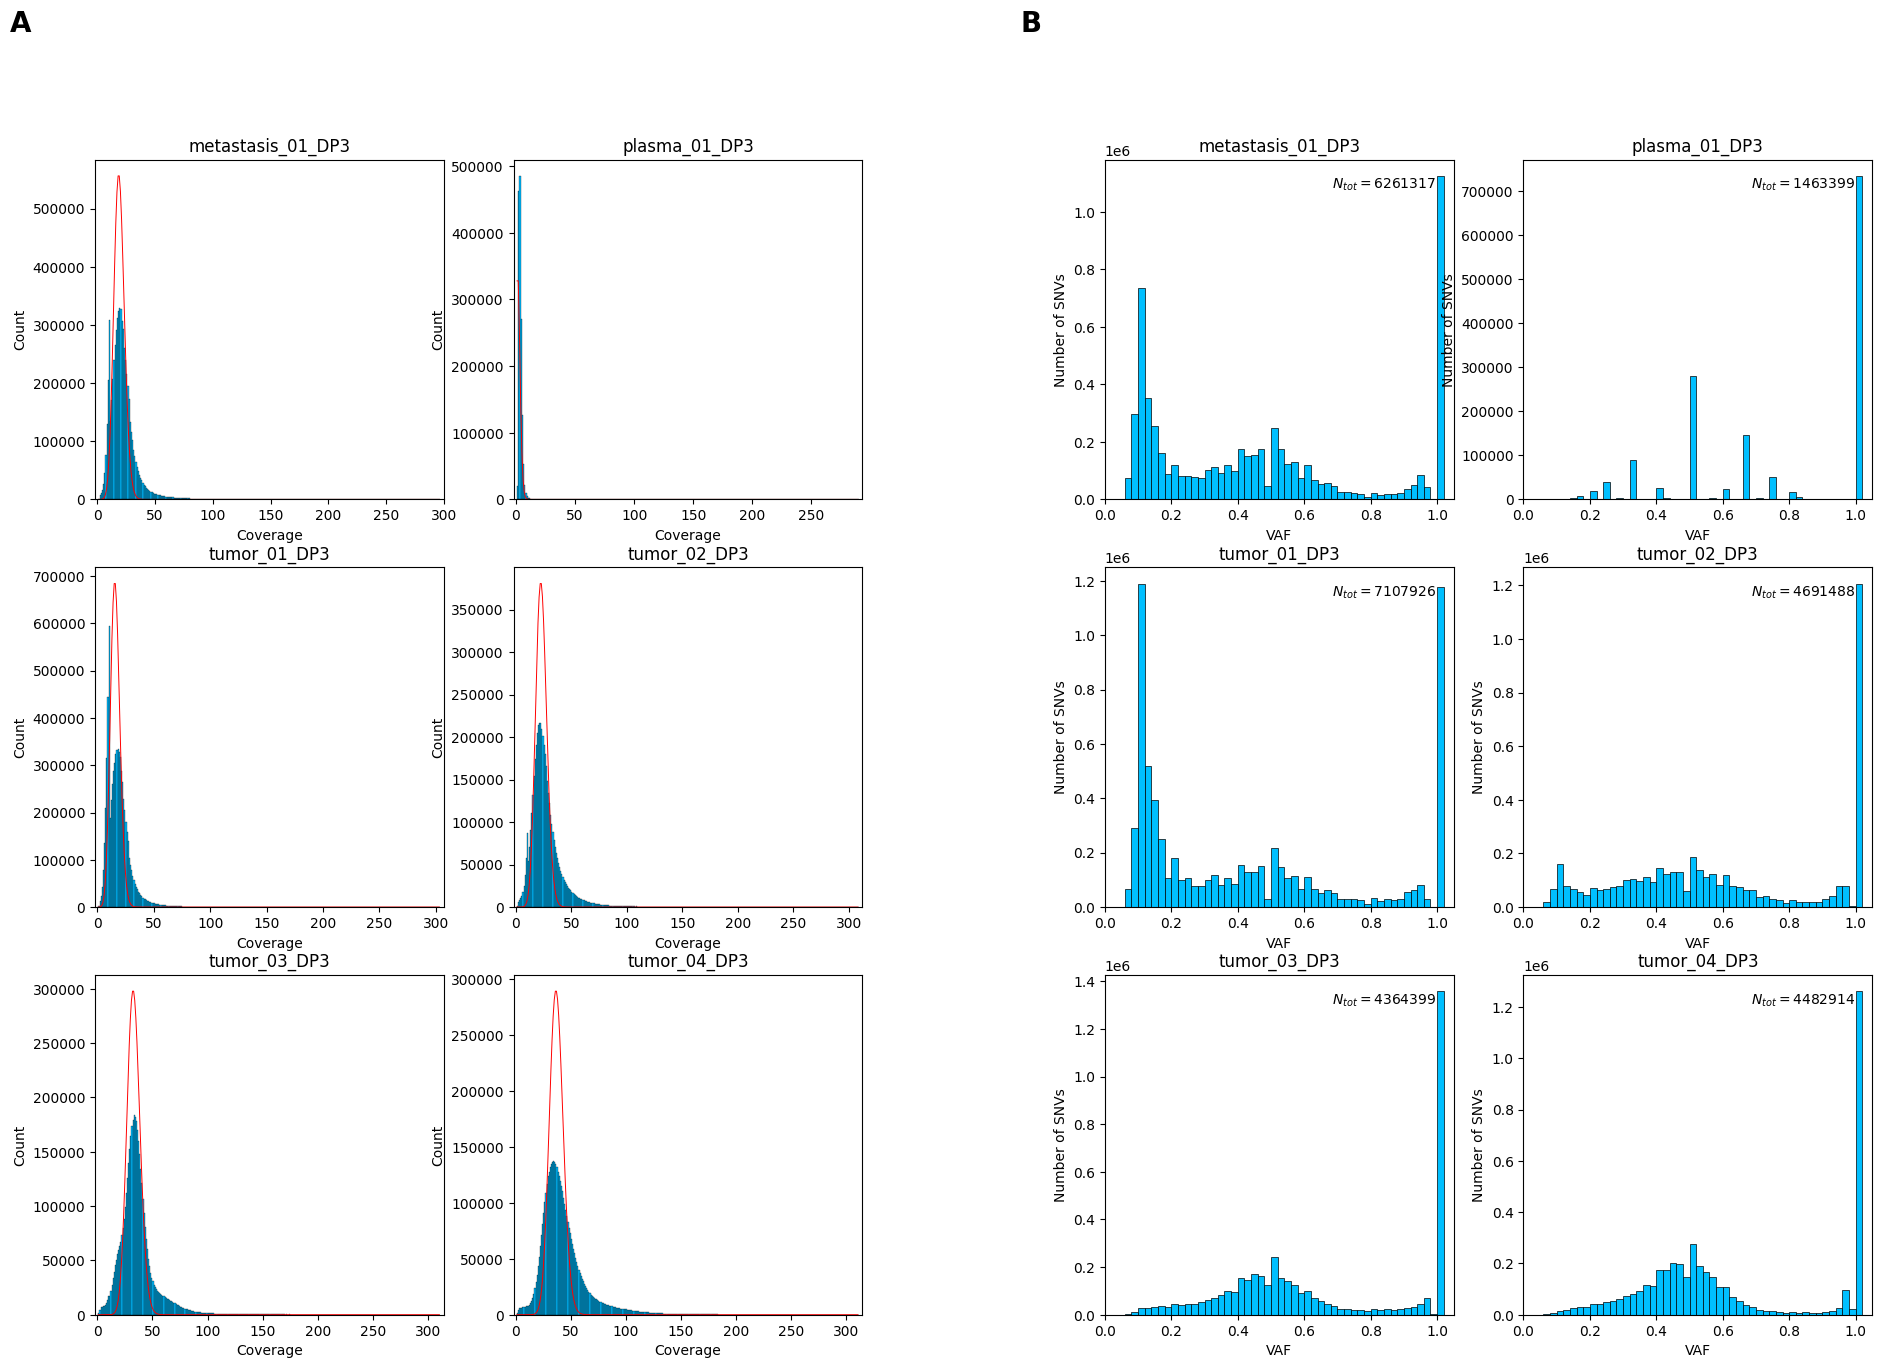

In [ ]:
fig = plt.figure(figsize=(20, 15)) 

subfigs = fig.subfigures(1, 2, wspace=0.02) 

# --- LEFT SIDE: PLOT A (Poisson Depth Distribution) ---
subfigs[0].suptitle('A', x=0.05, y=0.98, fontsize=20, fontweight='bold')
axes_left = subfigs[0].subplots(3, 2)
axes_left_flat = axes_left.flatten()

for i, (name, df) in enumerate(loaded_SVF_D3.items()):
    if i >= len(axes_left_flat):
        break
    
    short_title = name.replace('\\', '/').split('/')[-1]
    
    depth_distribution(df, ax=axes_left_flat[i], title=short_title, show_poisson=True)

# --- RIGHT SIDE: PLOT B (VAF Histograms) ---
subfigs[1].suptitle('B', x=0.05, y=0.98, fontsize=20, fontweight='bold')
axes_right = subfigs[1].subplots(3, 2)
axes_right_flat = axes_right.flatten()

bins_02 = np.arange(0.0, 1.2, 0.02)

for i, (name, vaf_data) in enumerate(SVF_pl.items()):
    if i >= len(axes_right_flat):
        break
        
    short_title = name.replace('\\', '/').split('/')[-1]
    
    ax = axes_right_flat[i]
    ax.hist(vaf_data, bins=bins_02, color='deepskyblue', edgecolor='black', linewidth=0.5)
    
    ax.set_title(short_title) 
    ax.set_xlabel("VAF")
    ax.set_ylabel("Number of SNVs")
    ax.set_xlim(0, 1.05)
    
    n_tot = len(vaf_data)
    ax.text(0.95, 0.95, f"$N_{{tot}} = {n_tot}$", 
            transform=ax.transAxes, ha='right', va='top')

plt.savefig("./figures/F1_depth_distribution_all_samples.pdf")
plt.show()

figure 2

In [7]:
#load vcf files from mutect and strelka intersection as pl df
csv_dir = Path("../SmallVariantsFrame")

for f in csv_dir.glob("*.csv"):

    var_name = f.stem + "_pl" 
    globals()[var_name] = pl.read_csv(f)

In [8]:
def map_aceseq_cn_to_variants(
    vcf_dir: str | Path, 
    aceseq_dir: str | Path, 
    keep_missing_value: bool = True,
    vcf_chrom_col: str = "chromosome", 
    vcf_pos_col: str = "position"      
) -> dict[str, pl.DataFrame]:
    
    vcf_path = Path(vcf_dir)
    aceseq_path = Path(aceseq_dir)
    processed_samples = {}
    aceseq_files = list(aceseq_path.glob("*.txt"))
    
    for vcf_file in vcf_path.glob("*.csv"):
        sample_name = vcf_file.stem  
        
        matching_aceseq = [f for f in aceseq_files if sample_name in f.name]
        
        if not matching_aceseq:
            print(f"Warning: No matching ACEseq file found for {sample_name}. Skipping...")
            continue
            
        aceseq_file = matching_aceseq[0]
        
        df_vcf = pl.read_csv(vcf_file)
        
        df_ace = pl.read_csv(
            aceseq_file,
            separator="\t",
            null_values="NA",
            schema_overrides={"#chromosome": pl.String}
        ).select([
            pl.col("#chromosome").alias(vcf_chrom_col),
            pl.col("start"),
            pl.col("end"),
            pl.col("TCN")
        ])
        
        df_vcf = df_vcf.with_columns([
            pl.col(vcf_chrom_col).cast(pl.String).str.replace("(?i)^chr", "").alias(vcf_chrom_col),
            pl.col(vcf_pos_col).cast(pl.Int64)
        ]).sort([vcf_chrom_col, vcf_pos_col])
        
        df_ace = df_ace.with_columns([
            pl.col(vcf_chrom_col).cast(pl.String).str.replace("(?i)^chr", "").alias(vcf_chrom_col),
            pl.col("start").cast(pl.Int64),
            pl.col("end").cast(pl.Int64)
        ]).sort([vcf_chrom_col, "start"])
        
        mapped_df = df_vcf.join_asof(
            df_ace,
            left_on=vcf_pos_col,
            right_on="start",
            by=vcf_chrom_col,
            strategy="backward"
        )
        
        mapped_df = mapped_df.with_columns(
            pl.when(pl.col(vcf_pos_col) <= pl.col("end"))
            .then(pl.col("TCN"))
            .otherwise(None)
            .alias("CN")
        )
        
        if not keep_missing_value:
            mapped_df = mapped_df.drop_nulls(subset=["CN"])
            
        processed_samples[sample_name] = mapped_df
        print(f"Successfully processed: {sample_name}")
        
    return processed_samples

In [ ]:
vcf_folder = "..\SmallVariantsFrame"
aceseq_folder = "..\provided_data\ACEseq_results"


with contextlib.redirect_stdout(io.StringIO()):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        mapped_variants_comp = map_aceseq_cn_to_variants(
            vcf_dir=vcf_folder,
            aceseq_dir=aceseq_folder,
            keep_missing_value=True,
            vcf_chrom_col="chrom",
            vcf_pos_col="pos"
        )

In [ ]:
purity_file = "../provided_data/Aceseq.txt"

df_purity = pl.read_csv(purity_file, separator=",")


purity_sample_col = "Sample"  
purity_val_col = "Purity"          

purity_dict = dict(zip(df_purity[purity_sample_col], df_purity[purity_val_col]))

for sample_name, df in mapped_variants_comp.items():
    
    matched_purity = None
    
    for p_sample_name, p_val in purity_dict.items():
        if sample_name in str(p_sample_name):
            matched_purity = p_val
            break
            
    if matched_purity is not None:
        print(f"Sample {sample_name} corrected with purity: {matched_purity}")
        
        mapped_variants_comp[sample_name] = df.with_columns(
            (pl.col("vaf") / matched_purity).alias("vaf_corrected")
        )
    else:
        print(f"Warning: No purity value found for {sample_name}. 'vaf_corrected' will be set to null.")
        
        mapped_variants_comp[sample_name] = df.with_columns(
            pl.lit(None).cast(pl.Float64).alias("vaf_corrected")
        )


print("\n--- Resulting DataFrame for metastasis_01_01 ---")
print(mapped_variants_comp["metastasis_01_01"].select(["chrom", "pos", "vaf", "CN", "vaf_corrected"]).head())

Sample metastasis_01_01 corrected with purity: 0.97
Sample tumor_01_01 corrected with purity: 0.9
Sample tumor_01_02 corrected with purity: 0.67
Sample tumor_01_03 corrected with purity: 0.91
Sample tumor_01_04 corrected with purity: 0.19

--- Resulting DataFrame for metastasis_01_01 ---
shape: (5, 5)
┌───────┬──────────┬──────────┬──────┬───────────────┐
│ chrom ┆ pos      ┆ vaf      ┆ CN   ┆ vaf_corrected │
│ ---   ┆ ---      ┆ ---      ┆ ---  ┆ ---           │
│ str   ┆ i64      ┆ f64      ┆ str  ┆ f64           │
╞═══════╪══════════╪══════════╪══════╪═══════════════╡
│ 1     ┆ 2541259  ┆ 0.090909 ┆ 2    ┆ 0.093721      │
│ 1     ┆ 7483175  ┆ 0.121212 ┆ 2    ┆ 0.124961      │
│ 1     ┆ 12242904 ┆ 0.081633 ┆ null ┆ 0.084157      │
│ 1     ┆ 16872517 ┆ 0.151261 ┆ 2    ┆ 0.155939      │
│ 1     ┆ 16879027 ┆ 0.258065 ┆ 2    ┆ 0.266046      │
└───────┴──────────┴──────────┴──────┴───────────────┘


In [13]:
# add information whether that SNV is mapped or not
for sample_name, df in mapped_variants_comp.items():
    
    mapped_variants_comp[sample_name] = df.with_columns(
        pl.when(pl.col("CN").is_not_null())
        .then(pl.lit("Mapped"))
        .otherwise(pl.lit("Unmapped"))
        .alias("label_comp")
    )

globals().update({f"corr_{name.replace('tumor', 'tum').replace('metastasis', 'met').replace('plasma', 'pla')}": df for name, df in mapped_variants_comp.items()})

load and correct with purple

In [30]:
csv_files = sorted(glob.glob("../Julia_SVF/mutect_vcf/*.csv"))

SVF_pl_mutect = {}

print("Loading files with Polars...")
for file in csv_files:
    base_name = os.path.splitext(file)[0]
    clean_name = base_name.replace("_julia", "_mutect_j")
    
    df = pl.read_csv(file)
    
    SVF_pl_mutect[clean_name] = df.get_column('vaf').to_numpy()
    
    print(f"Loaded: {clean_name} (N = {len(SVF_pl_mutect[clean_name])})")

print("\nAll data loaded ")

Loading files with Polars...
Loaded: ../Julia_SVF/mutect_vcf\metastasis_01_01_mutect_j (N = 531)
Loaded: ../Julia_SVF/mutect_vcf\plasma_01_01_mutect_j (N = 70)
Loaded: ../Julia_SVF/mutect_vcf\tumor_01_01_mutect_j (N = 687)
Loaded: ../Julia_SVF/mutect_vcf\tumor_01_02_mutect_j (N = 377)
Loaded: ../Julia_SVF/mutect_vcf\tumor_01_03_mutect_j (N = 284)
Loaded: ../Julia_SVF/mutect_vcf\tumor_01_04_mutect_j (N = 286)

All data loaded 


In [ ]:
mut_dir = Path("../Julia_SVF/mutect_vcf")
purple_dir = Path("../purple_results")
purity_file = purple_dir / "Purple_38_Ploidy_Purity.csv"

name_mapping = {
    "tumor_01": "tumor-01-01",
    "tumor_02": "tumor-01-02",
    "tumor_03": "tumor-01-03",
    "tumor_04": "tumor-01-04",
    "metastasis_01": "metastasis-01-01",
    "plasma_01": "plasma-01",
}

df_purity = pl.read_csv(purity_file)
purity_dict = dict(zip(df_purity["Sample"], df_purity["Purity"]))

mut_files = sorted(mut_dir.glob("*_julia*.csv"))
purple_cnv_files = list(purple_dir.glob("*.purple.cnv.somatic.tsv"))

mapped_results = {}

with contextlib.redirect_stdout(io.StringIO()):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)

        for vcf_path in mut_files:
            # Identify sample
            base_name = vcf_path.stem.replace("_julia", "")
            logical_id = name_mapping.get(base_name, base_name)

            # Load Mutect variants
            df_vcf = (
                pl.read_csv(vcf_path)
                .with_columns([
                    pl.col("chrom").cast(pl.String).str.replace("(?i)^chr", ""),
                    pl.col("pos").cast(pl.Int64),
                ])
                .sort(["chrom", "pos"])
            )

            matching_cnv = [f for f in purple_cnv_files if logical_id in f.name]
            if not matching_cnv:
                alt_search = logical_id.replace("_", "-")
                matching_cnv = [f for f in purple_cnv_files if alt_search in f.name]

            if matching_cnv:
                cnv_path = matching_cnv[0]

                df_purple = (
                    pl.read_csv(
                        cnv_path,
                        separator="\t",
                        schema_overrides={"chromosome": pl.String},
                    )
                    .select([
                        pl.col("chromosome").alias("chrom"),
                        pl.col("start").cast(pl.Int64),
                        pl.col("end").cast(pl.Int64),
                        pl.col("copyNumber").alias("TCN"),
                    ])
                    .with_columns(
                        pl.col("chrom").str.replace("(?i)^chr", "")
                    )
                    .sort(["chrom", "start"])
                )

                df_joined = df_vcf.join_asof(
                    df_purple,
                    left_on="pos",
                    right_on="start",
                    by="chrom",
                    strategy="backward",
                )

                df_joined = df_joined.with_columns(
                    pl.when(pl.col("pos") <= pl.col("end"))
                    .then(pl.col("TCN"))
                    .otherwise(None)
                    .alias("CN_purple")
                )
            else:
                df_joined = df_vcf.with_columns(
                    pl.lit(None).cast(pl.Float64).alias("CN_purple")
                )

            matched_purity_val = next(
                (v for k, v in purity_dict.items() if logical_id in k),
                None,
            )

            if matched_purity_val:
                p_factor = (
                    float(str(matched_purity_val).replace("%", "")) / 100.0
                    if "%" in str(matched_purity_val)
                    else float(matched_purity_val)
                )
                df_joined = df_joined.with_columns(
                    (pl.col("vaf") / p_factor).alias("vaf_corrected")
                )
            else:
                df_joined = df_joined.with_columns(
                    pl.col("vaf").alias("vaf_corrected")
                )

            mapped_results[base_name] = df_joined

print("\nProcessing complete.")



Processing complete.


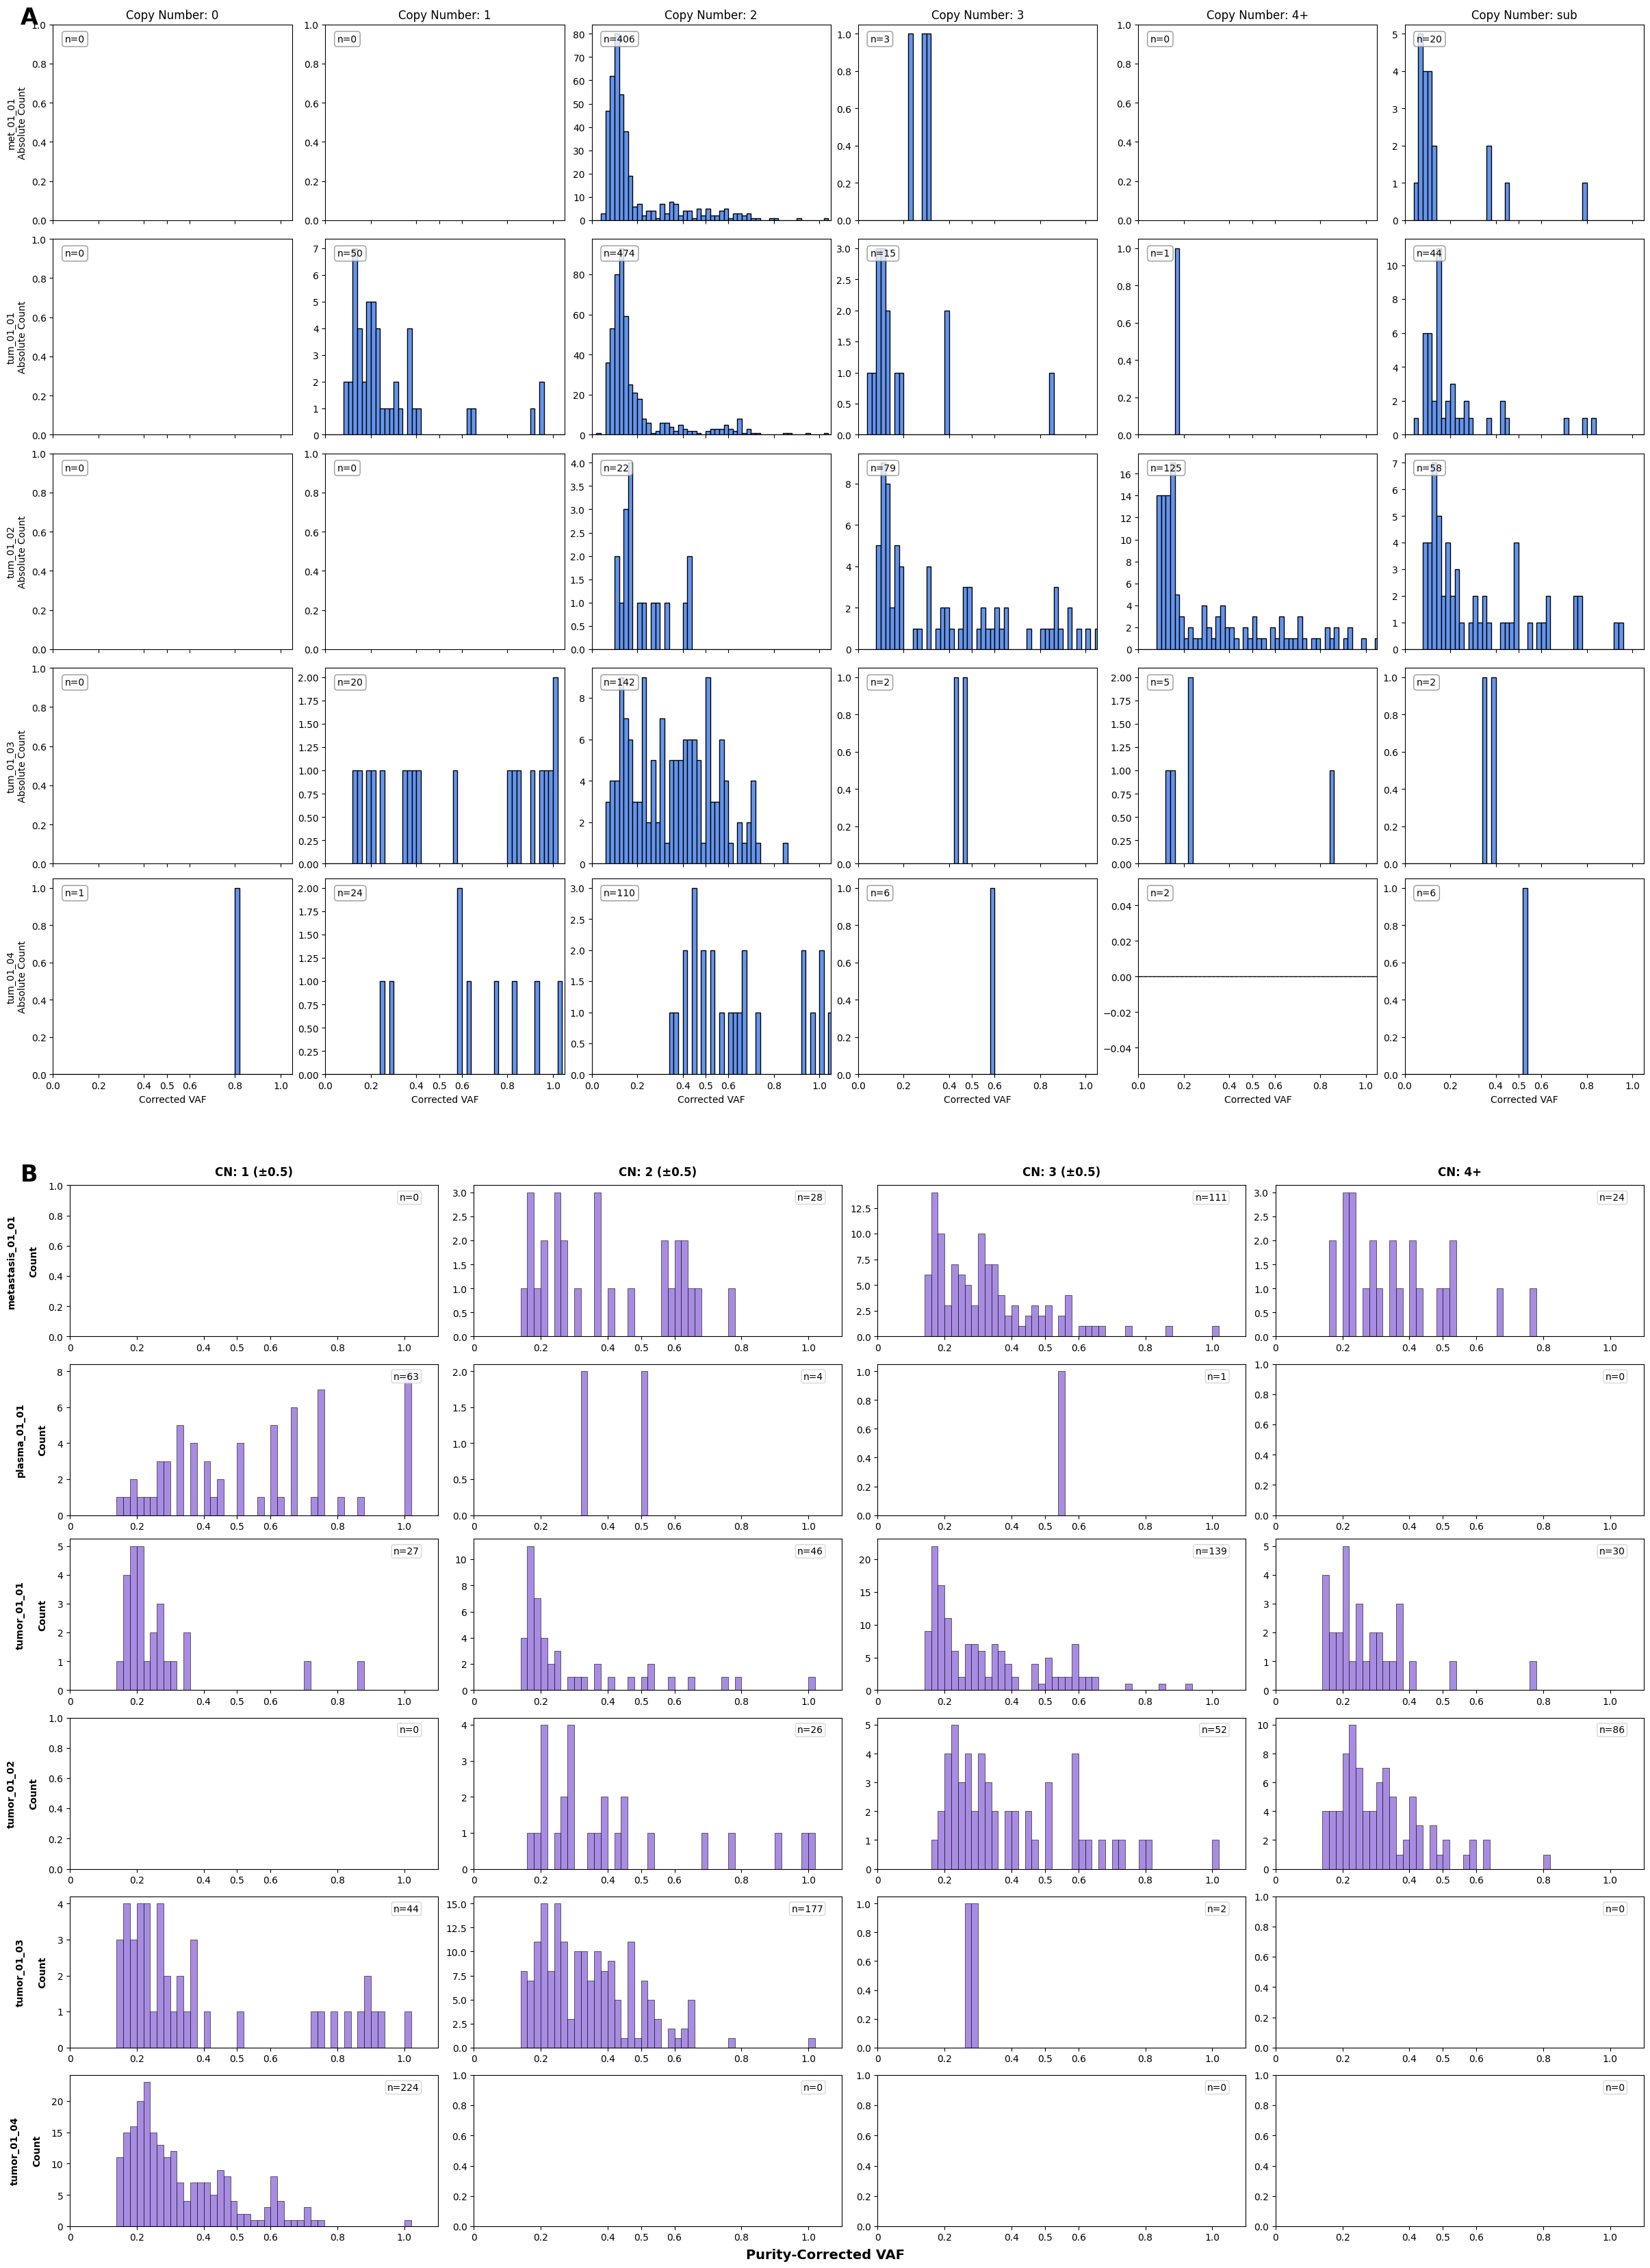

In [ ]:
# 1. TOP PLOT (A) -CN grouped by aceseq results
def group_cn(val):
    if val is None or str(val).lower() in ["null", "none"]:
        return None
    try:
        num = float(val)
        if num >= 4:
            return "4+"
        else:
            return str(int(num)) if num.is_integer() else str(val)
    except ValueError:
        return str(val)

for name in mapped_variants_comp:
    mapped_variants_comp[name] = mapped_variants_comp[name].with_columns(
        pl.col("CN").map_elements(group_cn, return_dtype=pl.Utf8).alias("CN_grouped")
    )

all_cns = set()
for df in mapped_variants_comp.values():
    cns = df.filter(pl.col("CN_grouped").is_not_null())["CN_grouped"].unique().to_list()
    all_cns.update([c for c in cns if c is not None])

def sort_cn_key(val):
    if val == "4+": return (0, 4.0)
    try: return (0, float(val))
    except ValueError: return (1, val)

sorted_cns = sorted(list(all_cns), key=sort_cn_key)

samples_A = list(mapped_variants_comp.keys())
nrows_A = len(samples_A)
ncols_A = len(sorted_cns)
plot_max_vaf = 1.05
vaf_bins_A = np.arange(0.0, plot_max_vaf + 0.02, 0.02)

# BOTTOM PLOT (B) - CN gouped by PURPLE results
samples_B = list(mapped_results.keys())
cn_window = 0.5  

cond_cn1 = (pl.col("CN_purple") >= 1.0 - cn_window) & (pl.col("CN_purple") <= 1.0 + cn_window)
cond_cn2 = (pl.col("CN_purple") >= 2.0 - cn_window) & (pl.col("CN_purple") <= 2.0 + cn_window)
cond_cn3 = (pl.col("CN_purple") >= 3.0 - cn_window) & (pl.col("CN_purple") <= 3.0 + cn_window)
cond_cn4 = (pl.col("CN_purple") >= 4.0)

columns_config = [
    (f"CN: 1 (±{cn_window})", cond_cn1),
    (f"CN: 2 (±{cn_window})", cond_cn2),
    (f"CN: 3 (±{cn_window})", cond_cn3),
    ("CN: 4+", cond_cn4),
]

nrows_B = len(samples_B)
ncols_B = len(columns_config)
vaf_bins_B = np.arange(0.0, 2.02, 0.02)
ticks_B = [0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]


fig = plt.figure(figsize=(max(ncols_A, ncols_B) * 4, (nrows_A + nrows_B) * 3), layout="constrained")

subfigs = fig.subfigures(2, 1, hspace=0.05)

# SUBFIGURE A 
subfigs[0].suptitle('A', x=0.01, y=1.0, fontsize=24, fontweight='bold', ha='left')
axes_A = subfigs[0].subplots(nrows=nrows_A, ncols=ncols_A, squeeze=False, sharex=True)

for i, sample_name in enumerate(samples_A):
    df = mapped_variants_comp[sample_name]
    for j, cn_val in enumerate(sorted_cns):
        ax = axes_A[i, j]
        
        subset = df.filter(
            (pl.col("CN_grouped") == cn_val) & 
            (pl.col("vaf_corrected").is_not_null())
        )["vaf_corrected"].to_numpy()
        
        n_variants = len(subset)
        if n_variants > 0:
            ax.hist(subset, bins=vaf_bins_A, color='cornflowerblue', edgecolor='black')
        
        ax.text(0.05, 0.95, f"n={n_variants}", transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))
        
        if i == 0:
            ax.set_title(f"Copy Number: {cn_val}")
            
        if i == nrows_A - 1:
            ax.set_xlabel("Corrected VAF")
            ax.set_xticks([0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]) 
            ax.set_xlim(0.0, plot_max_vaf) 
                
        if j == 0:
            short_name = sample_name.replace("tumor", "tum").replace("metastasis", "met").replace("plasma", "pla")
            ax.set_ylabel(f"{short_name}\nAbsolute Count")

# SUBFIGURE B 
subfigs[1].suptitle('B', x=0.01, y=1.0, fontsize=24, fontweight='bold', ha='left')
axes_B = subfigs[1].subplots(nrows=nrows_B, ncols=ncols_B, squeeze=False, sharex=False)

for row_idx, sample_name in enumerate(samples_B):
    df = mapped_results[sample_name]
    for col_idx, (col_title, condition) in enumerate(columns_config):
        ax = axes_B[row_idx, col_idx]
        
        plot_df = df.filter(condition & (pl.col("vaf_corrected") > 0.15))
        vaf_data = plot_df["vaf_corrected"].drop_nulls().to_numpy()
        
        n_count = len(vaf_data)
        if n_count > 0:
            ax.hist(vaf_data, bins=vaf_bins_B, color='mediumpurple', edgecolor='black', alpha=0.8, linewidth=0.5)
            
        if row_idx == 0:
            ax.set_title(col_title, fontweight='bold', pad=10)
        if col_idx == 0:
            ax.set_ylabel(f"{sample_name}\n\nCount", fontweight='bold', labelpad=10)
            
        ax.set_xlim(0., 1.1)
        ax.set_xticks(ticks_B)
        ax.set_xticklabels([str(t) for t in ticks_B])
        
        ax.text(0.95, 0.95, f"n={n_count}", transform=ax.transAxes, ha='right', va='top', 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='lightgray'))

subfigs[1].supxlabel("Purity-Corrected VAF", fontsize=14, fontweight='bold')
plt.savefig("figures/F2_combined_vaf_histograms.pdf")
plt.show()

figure 3

In [ ]:
base_path = "../provided_data/Sarah_Wilms_Tumor_Data/Wilms"
bi_sample = ["SJWLM030261", "SJWLM031124", "SJWLM031295", "SJWLM031677"]
bi_folder_path = "../provided_data/Sarah_Wilms_Tumor_Data/bilateral_Wilms/SmallVariantFrame/"

pl_dfs = {}

for sample in bi_sample:
    file_path = os.path.join(bi_folder_path, f"{sample}_snvs.csv")
    
    if os.path.exists(file_path):
        pl_dfs[sample] = pl.read_csv(file_path)
        print(f"Loaded {sample}: {pl_dfs[sample].shape[0]} rows")
    else:
        print(f"Warning: {file_path} not found.")



Loaded SJWLM030261: 696 rows
Loaded SJWLM031124: 339 rows
Loaded SJWLM031295: 634 rows
Loaded SJWLM031677: 953 rows


In [ ]:
cnv_dir = "../provided_data/Sarah_Wilms_Tumor_Data/bilateral_Wilms/Aceseq"

for sample, df in pl_dfs.items():
    search_pattern = os.path.join(cnv_dir, f"*{sample}*comb_pro*.txt")
    matching_files = glob.glob(search_pattern)
    
    if matching_files:
        cnv_path = matching_files[0] 
        
        try:
            cnv_df = pl.read_csv(
                cnv_path, 
                separator="\t",
                schema_overrides={
                    "#chromosome": pl.Utf8,
                    "A": pl.Utf8
                },
                null_values=["NA"]
            )
            
            df = df.with_columns(
                pl.col("chrom").str.replace(r"(?i)^chr", "")
            )
            
            # Perform the Range Join
            pl_dfs[sample] = df.join_where(
                cnv_df,
                pl.col("chrom") == pl.col("#chromosome"),
                pl.col("pos") >= pl.col("start"),
                pl.col("pos") <= pl.col("end"),
                suffix="_cnv"
            ).drop(["#chromosome", "start", "end"])
            
            # Quick check to make sure it didn't empty out the dataframe
            row_count = pl_dfs[sample].shape[0]
            print(f"Matched CN data for {sample}. Rows remaining: {row_count}")
            
        except Exception as e:
            print(f"Error processing {sample}: {e}")
    else:
        print(f"Warning: No CNV file found for {sample}")

Matched CN data for SJWLM030261. Rows remaining: 689
Matched CN data for SJWLM031124. Rows remaining: 333
Matched CN data for SJWLM031295. Rows remaining: 624
Matched CN data for SJWLM031677. Rows remaining: 949


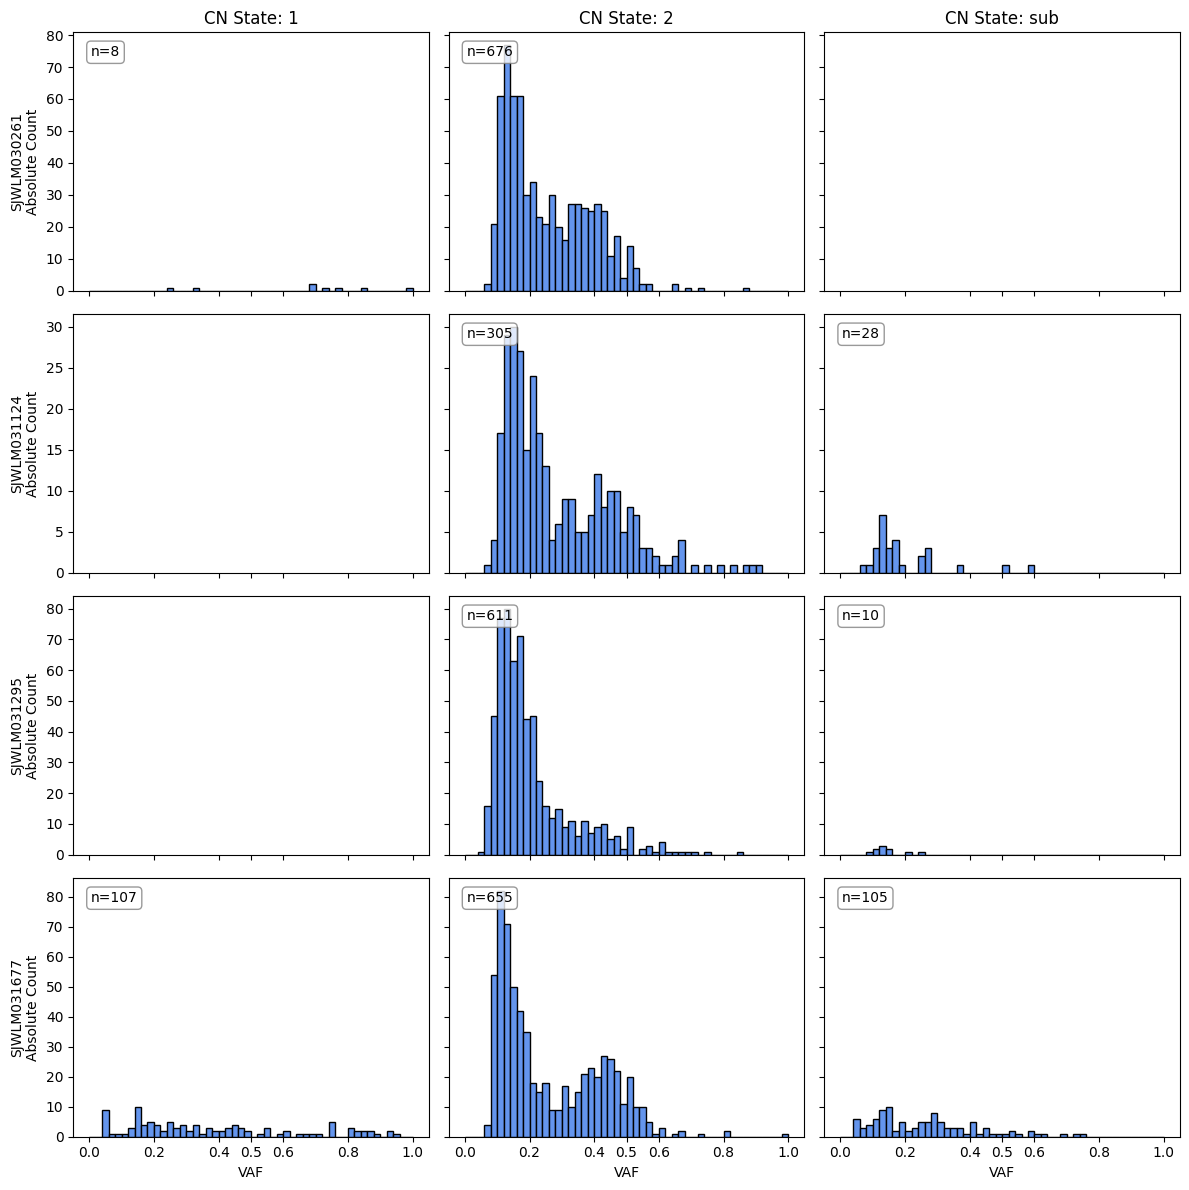

In [ ]:
cn_col = "TCN" 
global_max_vaf = 0.0

valid_tcns = set()

for name, df in pl_dfs.items():
    if cn_col not in df.columns:
        continue
        
    tcns = df.filter(pl.col(cn_col).is_not_null())[cn_col].cast(pl.Utf8, strict=False).unique().to_list()
    
    for t in tcns:
        if t is None or str(t).lower() == "nan":
            continue
            
        n_count = len(df.filter(
            (pl.col(cn_col).cast(pl.Utf8, strict=False) == str(t)) & 
            (pl.col("vaf").is_not_null())
        ))
        
        if n_count > 50:
            valid_tcns.add(str(t))
            
    local_max = df.select(pl.col("vaf").max()).item()
    if local_max is not None and local_max > global_max_vaf:
        global_max_vaf = local_max

def sort_cn_key(val):
    try:
        return (0, float(val)) 
    except ValueError:
        return (1, val)       

sorted_tcns = sorted(list(valid_tcns), key=sort_cn_key)

if not sorted_tcns:
    raise ValueError("No copy number states found with n > 50! Try lowering the threshold.")

# 3. Plot Setup
vaf_bins = np.arange(0.0, global_max_vaf + 0.02, 0.02)
samples = list(pl_dfs.keys())
nrows = len(samples)
ncols = len(sorted_tcns)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False, sharex=True, sharey='row')

for i, sample_name in enumerate(samples):
    df = pl_dfs[sample_name]
    
    for j, tcn_val in enumerate(sorted_tcns):
        ax = axes[i, j]
        
        if cn_col in df.columns:
            subset = df.filter(
                (pl.col(cn_col).cast(pl.Utf8, strict=False) == tcn_val) & 
                (pl.col("vaf").is_not_null())
            )["vaf"].to_numpy()
        else:
            subset = np.array([])
            
        n_variants = len(subset)
        
        if n_variants > 0:
            ax.hist(subset, bins=vaf_bins, color='cornflowerblue', edgecolor='black')
            
            ax.text(
                0.05, 0.95, f"n={n_variants}", 
                transform=ax.transAxes, 
                fontsize=10, 
                verticalalignment='top', 
                horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
            )
        # else:
            # Leave a faint watermark so you know it wasn't an error, just low counts
            # ax.text(0.5, 0.5, f"n={n_variants}\n(Filtered)", 
            #         transform=ax.transAxes, ha='center', va='center', color='gray', alpha=0.5)

        if i == 0:
            ax.set_title(f"CN State: {tcn_val}")
            
        if i == nrows - 1:
            ax.set_xlabel("VAF")
            standard_ticks = np.arange(0.0, global_max_vaf + 0.2, 0.2)
            new_ticks = np.unique(np.append(standard_ticks, 0.5)) 
            ax.set_xticks(new_ticks)
                
        if j == 0:
            short_name = sample_name.replace("tumor", "tum").replace("metastasis", "met").replace("plasma", "pla")
            ax.set_ylabel(f"{short_name}\nAbsolute Count")

plt.tight_layout()
plt.savefig("figures/F3_Sarah_Wilms_VAF_by_CN.pdf")
plt.show()

figure 4

In [54]:
from matplotlib_venn import venn2, venn3

In [55]:
csv_dir = Path("../SmallVariantsFrame")

all_raw_samples = {}
for f in csv_dir.glob("*.csv"):
    var_name = f.stem + "_pl" 
    df = pl.read_csv(f)
    globals()[var_name] = df
    all_raw_samples[f.stem] = df


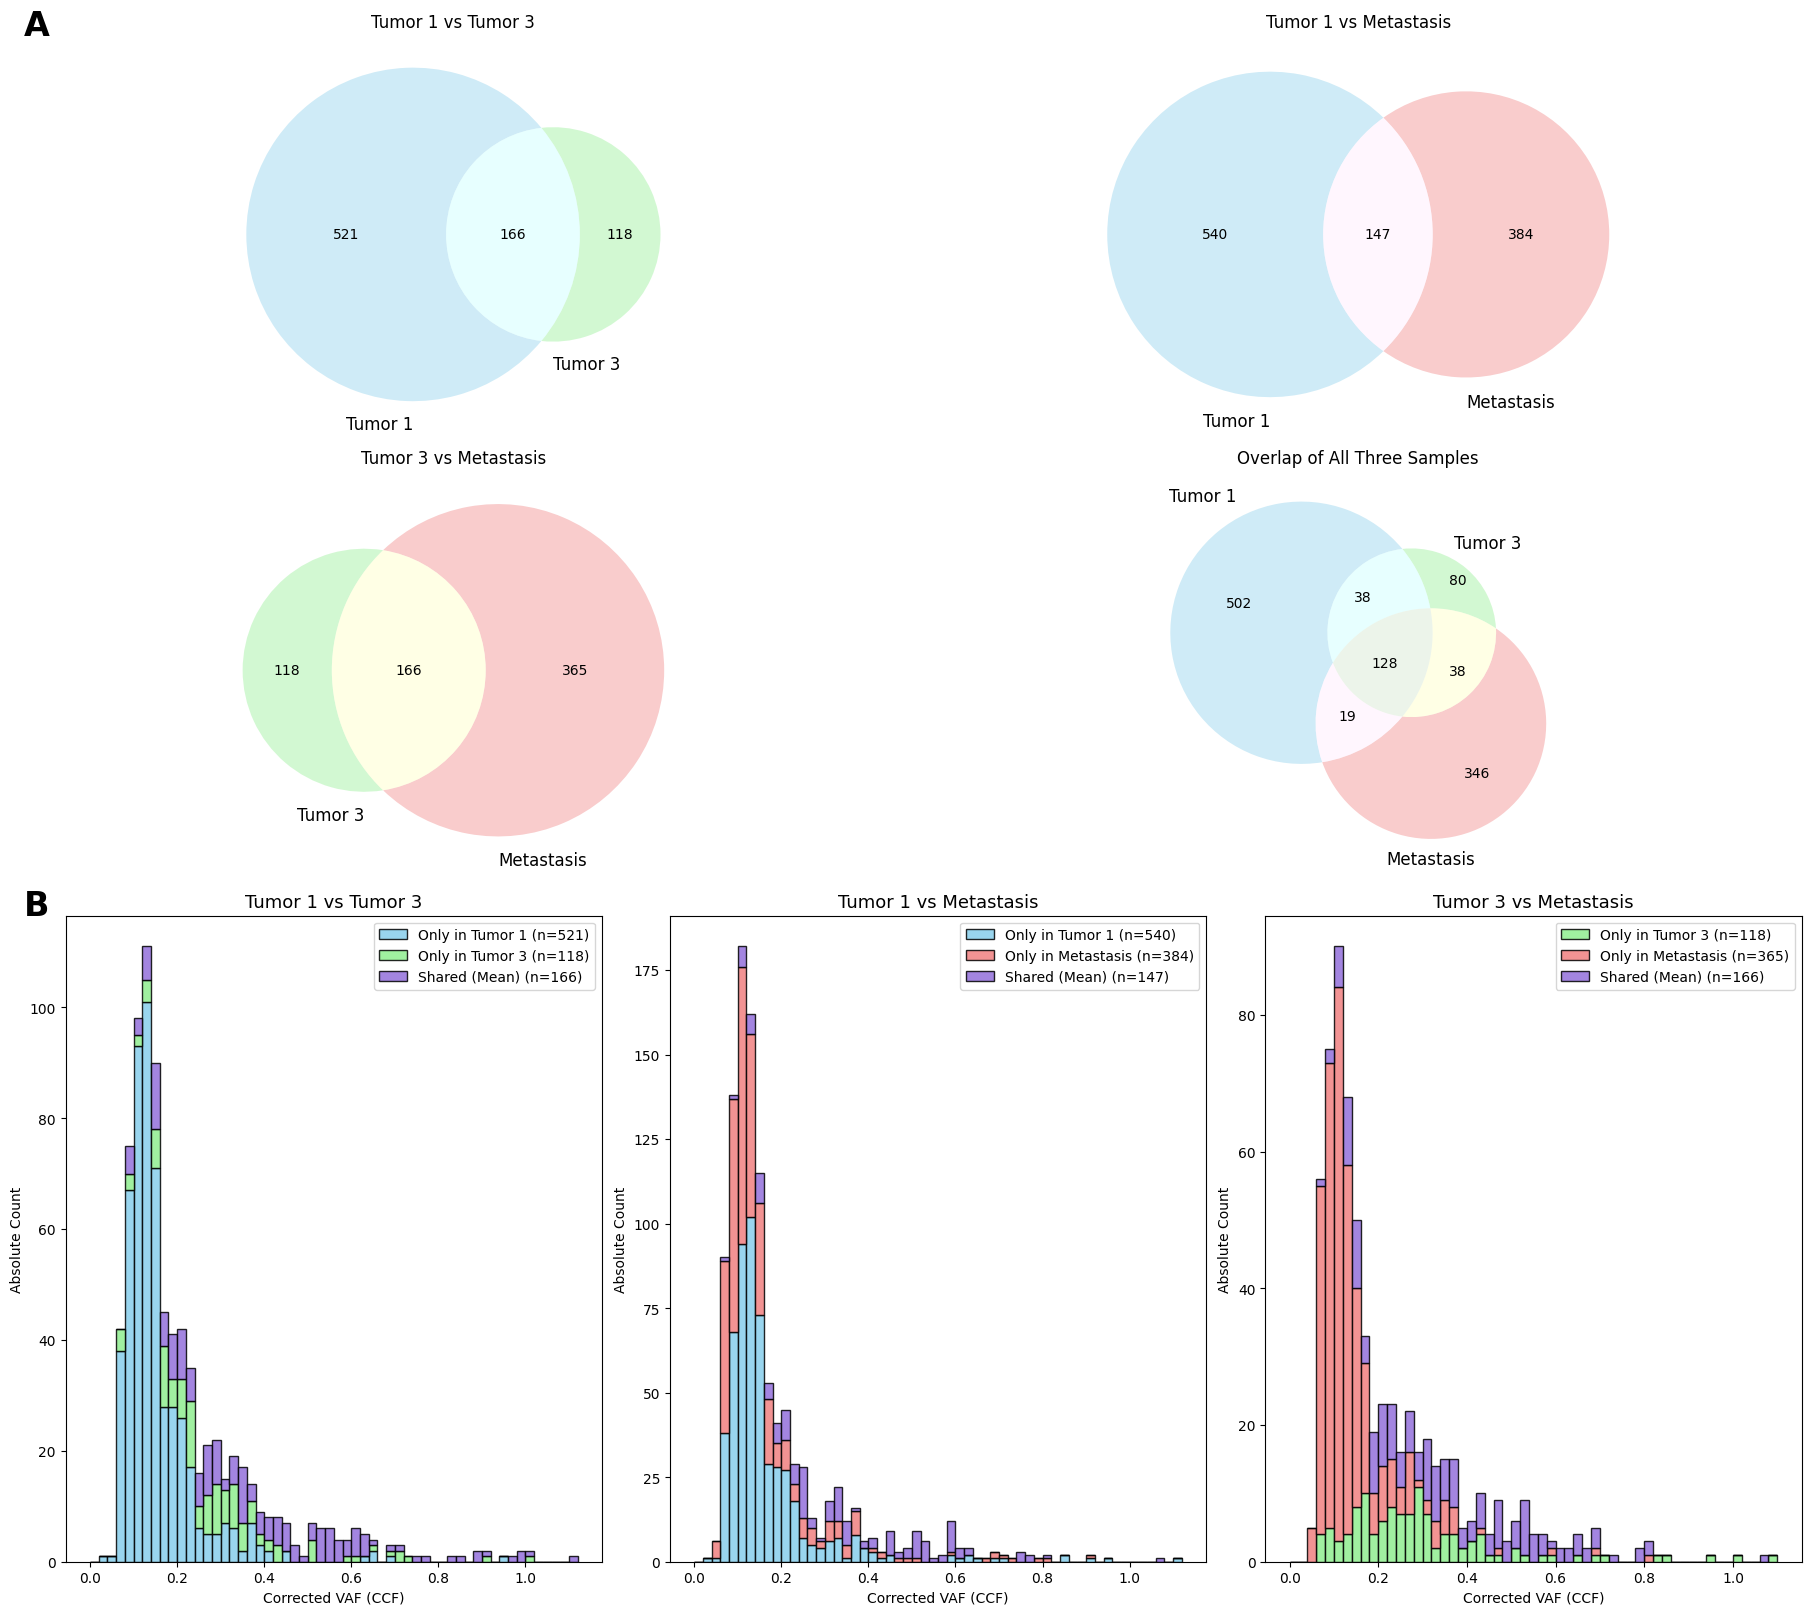

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib_venn import venn2, venn3

name_t1 = "tumor_01_01"
name_t3 = "tumor_01_03"
name_met = "metastasis_01_01"

set_t1 = set(all_raw_samples[name_t1].drop_nulls("id")["id"].to_list())
set_t3 = set(all_raw_samples[name_t3].drop_nulls("id")["id"].to_list())
set_met = set(all_raw_samples[name_met].drop_nulls("id")["id"].to_list())

def get_corrected_vafs(df, id_set):
    return df.filter(pl.col("id").is_in(id_set) & pl.col("vaf_corrected").is_not_null())["vaf_corrected"].to_numpy()

def plot_pairwise_vaf_histogram(ax, name_a, name_b, label_a, label_b, col_a, col_b, color_shared='mediumpurple'):
    df_a = mapped_variants_comp[name_a]
    df_b = mapped_variants_comp[name_b]

    set_a = set(df_a.drop_nulls("id")["id"].to_list())
    set_b = set(df_b.drop_nulls("id")["id"].to_list())

    only_a = set_a - set_b
    only_b = set_b - set_a
    shared = set_a & set_b

    v_only_a = get_corrected_vafs(df_a, only_a)
    v_only_b = get_corrected_vafs(df_b, only_b)
    
    df_shared_a = df_a.filter(pl.col("id").is_in(shared)).select(["id", "vaf_corrected"])
    df_shared_b = df_b.filter(pl.col("id").is_in(shared)).select(["id", "vaf_corrected"])
    
    merged_shared = df_shared_a.join(df_shared_b, on="id", suffix="_b")
    v_shared_mean = ((merged_shared["vaf_corrected"] + merged_shared["vaf_corrected_b"]) / 2).to_numpy()

    all_vafs = np.concatenate([v_only_a, v_only_b, v_shared_mean])
    max_vaf = all_vafs.max() if len(all_vafs) > 0 else 1.0
    vaf_bins = np.arange(0.0, max_vaf + 0.02, 0.02)

    ax.hist([v_only_a, v_only_b, v_shared_mean], bins=vaf_bins, stacked=True, 
            color=[col_a, col_b, color_shared], edgecolor='black', alpha=0.85,
            label=[f'Only in {label_a} (n={len(v_only_a)})', 
                   f'Only in {label_b} (n={len(v_only_b)})', 
                   f'Shared (Mean) (n={len(v_shared_mean)})'])

    ax.set_title(f"{label_a} vs {label_b}", fontsize=13)
    ax.set_xlabel("Corrected VAF (CCF)")
    ax.set_ylabel("Absolute Count")
    ax.legend(loc='upper right')

# Create the main figure and split into Top and Bottom subfigures
fig = plt.figure(figsize=(18, 16), layout='constrained')
subfigs = fig.subfigures(nrows=2, ncols=1, height_ratios=[1.2, 1])

# SUBFIGURE A - Venn Diagrams (2x2)
subfigs[0].suptitle('A', x=0.01, y=1.0, fontsize=24, fontweight='bold', ha='left')
axes_A = subfigs[0].subplots(nrows=2, ncols=2)

# Plot 1: Tumor 1 vs Tumor 3
venn2([set_t1, set_t3], set_labels=('Tumor 1', 'Tumor 3'), set_colors=('skyblue', 'lightgreen'), ax=axes_A[0, 0])
axes_A[0, 0].set_title("Tumor 1 vs Tumor 3")

# Plot 2: Tumor 1 vs Metastasis
venn2([set_t1, set_met], set_labels=('Tumor 1', 'Metastasis'), set_colors=('skyblue', 'lightcoral'), ax=axes_A[0, 1])
axes_A[0, 1].set_title("Tumor 1 vs Metastasis")

# Plot 3: Tumor 3 vs Metastasis
venn2([set_t3, set_met], set_labels=('Tumor 3', 'Metastasis'), set_colors=('lightgreen', 'lightcoral'), ax=axes_A[1, 0])
axes_A[1, 0].set_title("Tumor 3 vs Metastasis")

# Plot 4: All three together
venn3([set_t1, set_t3, set_met], set_labels=('Tumor 1', 'Tumor 3', 'Metastasis'), set_colors=('skyblue', 'lightgreen', 'lightcoral'), ax=axes_A[1, 1])
axes_A[1, 1].set_title("Overlap of All Three Samples")

# SUBFIGURE B - Histograms (1x3)
subfigs[1].suptitle('B', x=0.01, y=1.0, fontsize=24, fontweight='bold', ha='left')
axes_B = subfigs[1].subplots(nrows=1, ncols=3, sharey=False)

color_t1 = 'skyblue'
color_t3 = 'lightgreen'
color_met = 'lightcoral'

# Plot 1: Tumor 1 vs Tumor 3 
plot_pairwise_vaf_histogram(axes_B[0], name_t1, name_t3, "Tumor 1", "Tumor 3", color_t1, color_t3)

# Plot 2: Tumor 1 vs Metastase 
plot_pairwise_vaf_histogram(axes_B[1], name_t1, name_met, "Tumor 1", "Metastasis", color_t1, color_met)

# Plot 3: Tumor 3 vs Metastase 
plot_pairwise_vaf_histogram(axes_B[2], name_t3, name_met, "Tumor 3", "Metastasis", color_t3, color_met)

plt.savefig("./figures/F4_venn_and_vaf_histograms.pdf")
plt.show()

figure 5 (table)

In [6]:
import textwrap

In [ ]:
vcf_files = sorted(glob.glob("../vcf_files_dkfz_pipeline/*.vcf.gz"))
loaded_sequils = {}

for f in vcf_files:
    clean_id = os.path.basename(f).split("_hg19")[0].replace("-", "_")
    
    frame = SmallVariantsFrame.from_vcf(f, refgenome="hg19")
    frame.add_driver_annotation(driver_list='intogen')
    
    loaded_sequils[clean_id] = frame
    globals()[f"df_{clean_id}"] = pd.DataFrame(frame)

print(f"Clean variables created: {[k for k in globals() if k.startswith('df_') and '/' not in k]}")

INFO: using sample_metastasis-01-01_OE0290-PED_2LB-053 as sampleID
INFO: using sample_plasma-01-01_OE0290-PED_2LB-053 as sampleID
INFO: using sample_tumor-01-01_OE0290-PED_2LB-053 as sampleID
INFO: using sample_tumor-01-02_OE0290-PED_2LB-053 as sampleID
INFO: using sample_tumor-01-03_OE0290-PED_2LB-053 as sampleID
INFO: using sample_tumor-01-04_OE0290-PED_2LB-053 as sampleID
Clean variables created: ['df_metastasis_01_01', 'df_plasma_01_01', 'df_tumor_01_01', 'df_tumor_01_02', 'df_tumor_01_03', 'df_tumor_01_04']


In [ ]:
purity_map = {
    "metastasis_01_01": 0.97,
    "tumor_01_01": 0.90,
    "tumor_01_02": 0.67,
    "tumor_01_03": 0.91,
    "tumor_01_04": 0.19,
    "plasma_01_01": 1.0  # no purity correction, as no aceseq value not known
}

vcf_files = sorted(glob.glob("../vcf_files_dkfz_pipeline/*.vcf.gz"))

for f in vcf_files:
    clean_id = os.path.basename(f).split("_hg19")[0].replace("-", "_")
    purity = purity_map.get(clean_id, 1.0)
    
    frame = SmallVariantsFrame.from_vcf(f, refgenome="hg19")
    frame.add_driver_annotation(driver_list='intogen')

    #frame.add_driver_annotation(driver_list='intogen', region='exonic')
    #frame = frame.add_driver_annotation(driver_list='intogen')

    
    df = pd.DataFrame(frame)
    if "vaf" in df.columns:
        df["vaf_corrected"] = (df["vaf"] / purity).clip(upper=2.0)
    
    globals()[f"df_{clean_id}"] = df
    print(f"Finalized df_{clean_id} | Purity: {purity}")

all_drivers = [
    globals()[n].assign(sample=n) 
    for n in globals() 
    if n.startswith('df_') and n != 'df_hg19' and isinstance(globals()[n], pd.DataFrame)
]

all_drivers = [globals()[n].assign(sample=n) for n in globals() if n.startswith('df_') and n != 'df_hg19']
df_final_drivers = pd.concat(all_drivers).query("is_driver == True")

INFO: using sample_metastasis-01-01_OE0290-PED_2LB-053 as sampleID
Finalized df_metastasis_01_01 | Purity: 0.97
INFO: using sample_plasma-01-01_OE0290-PED_2LB-053 as sampleID
Finalized df_plasma_01_01 | Purity: 1.0
INFO: using sample_tumor-01-01_OE0290-PED_2LB-053 as sampleID
Finalized df_tumor_01_01 | Purity: 0.9
INFO: using sample_tumor-01-02_OE0290-PED_2LB-053 as sampleID
Finalized df_tumor_01_02 | Purity: 0.67
INFO: using sample_tumor-01-03_OE0290-PED_2LB-053 as sampleID
Finalized df_tumor_01_03 | Purity: 0.91
INFO: using sample_tumor-01-04_OE0290-PED_2LB-053 as sampleID
Finalized df_tumor_01_04 | Purity: 0.19


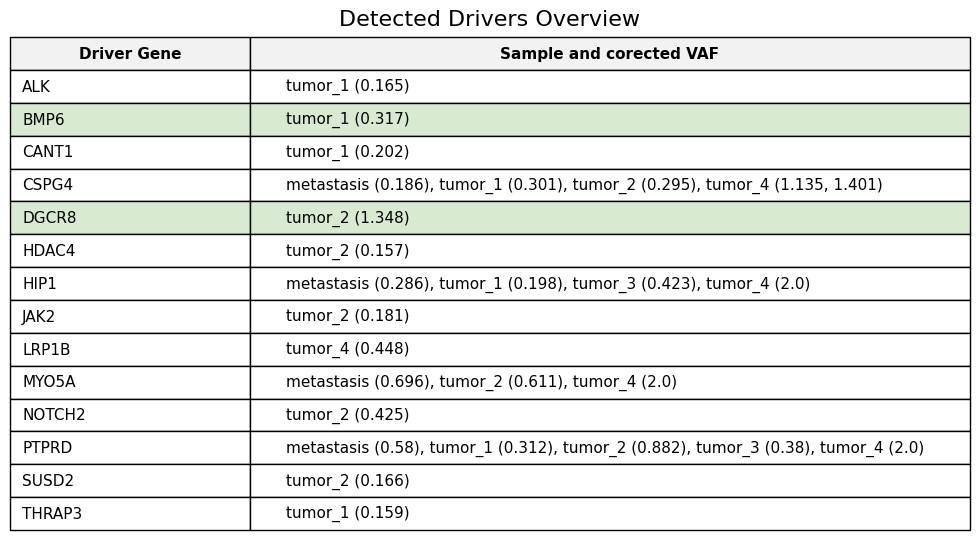

In [ ]:
vaf_threshold = 0.15

sample_rename_dict = {
    "plasma_01_01": "plasma",
    "metastasis_01_01": "metastasis",
    "tumor_01_01": "tumor_1",
    "tumor_01_02": "tumor_2",
    "tumor_01_03": "tumor_3",
    "tumor_01_04": "tumor_4"
}

sample_df_names = [k for k, v in globals().items() 
                   if isinstance(k, str) and k.startswith('df_') 
                   and isinstance(v, pd.DataFrame) 
                   and k not in ['df_hg19', 'df_final_drivers', 'df_purity', 'df_vcf']]

driver_records = []

for df_name in sample_df_names:
    df = globals()[df_name]
    if 'is_driver' in df.columns and df['is_driver'].any():
        raw_name = df_name.replace('df_', '')
        
        clean_name = sample_rename_dict.get(raw_name, raw_name)
        
        cols = df.columns.tolist()
        gene_col = next((c for c in cols if c.lower() in ['gene_symbol', 'symbol', 'gene']), 'Gene')
        vaf_col = 'vaf_corrected' if 'vaf_corrected' in cols else 'vaf'
        
        drivers_df = df[df['is_driver'] == True]
        for _, row in drivers_df.iterrows():
            vaf_val = round(row[vaf_col], 3)
            if vaf_val >= vaf_threshold:
                driver_records.append({'Gene': row[gene_col], 'Sample': clean_name, 'VAF': vaf_val})

if not driver_records:
    print(f"No drivers found with a VAF >= {vaf_threshold}.")
else:
    master_df = pd.DataFrame(driver_records)
    
    sample_grouped = master_df.groupby(['Gene', 'Sample'])['VAF'].apply(
        lambda vafs: ", ".join(vafs.astype(str))
    ).reset_index()
    
    sample_grouped['Sample_VAF'] = sample_grouped['Sample'] + " (" + sample_grouped['VAF'] + ")"
    
    summary_df = sample_grouped.groupby('Gene')['Sample_VAF'].apply(lambda x: ', '.join(x)).reset_index()
    summary_df.columns = ['Driver Gene', 'Sample and corected VAF']

    wrap_width = 100  
    summary_df['Sample and corected VAF'] = summary_df['Sample and corected VAF'].apply(
        lambda x: textwrap.fill(x, width=wrap_width)
    )

    fig, ax = plt.subplots(figsize=(10, max(2.0, len(summary_df) * 0.4))) 
    ax.axis('off')
    
    table = ax.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        loc='center',
        cellLoc='left',
        colWidths=[0.25, 0.75], 
        bbox=[0, 0, 1, 1]       
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    genes_to_highlight = ['BMP6', 'DGCR8']
    
    for (row, col), cell in table.get_celld().items():
        cell.PAD = 0.05 
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')
            cell.set_text_props(ha='center') 
        else:
            current_gene = summary_df.iloc[row - 1, 0]
            if current_gene in genes_to_highlight:
                cell.set_facecolor('#d9ead3') 

    plt.suptitle("Detected Drivers Overview", fontsize=16, y=0.95)
    
    plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02) 
    
    plt.savefig("figures/F5_driver_table_0_15_threshold.pdf")
    plt.show()

## Supplementary figures

supplementary figure 1

In [16]:
exome_tumor_3 = SmallVariantsFrame.from_csv("../Julia_SVF/All_Results/tumor_01_01_DP3_exome.csv")


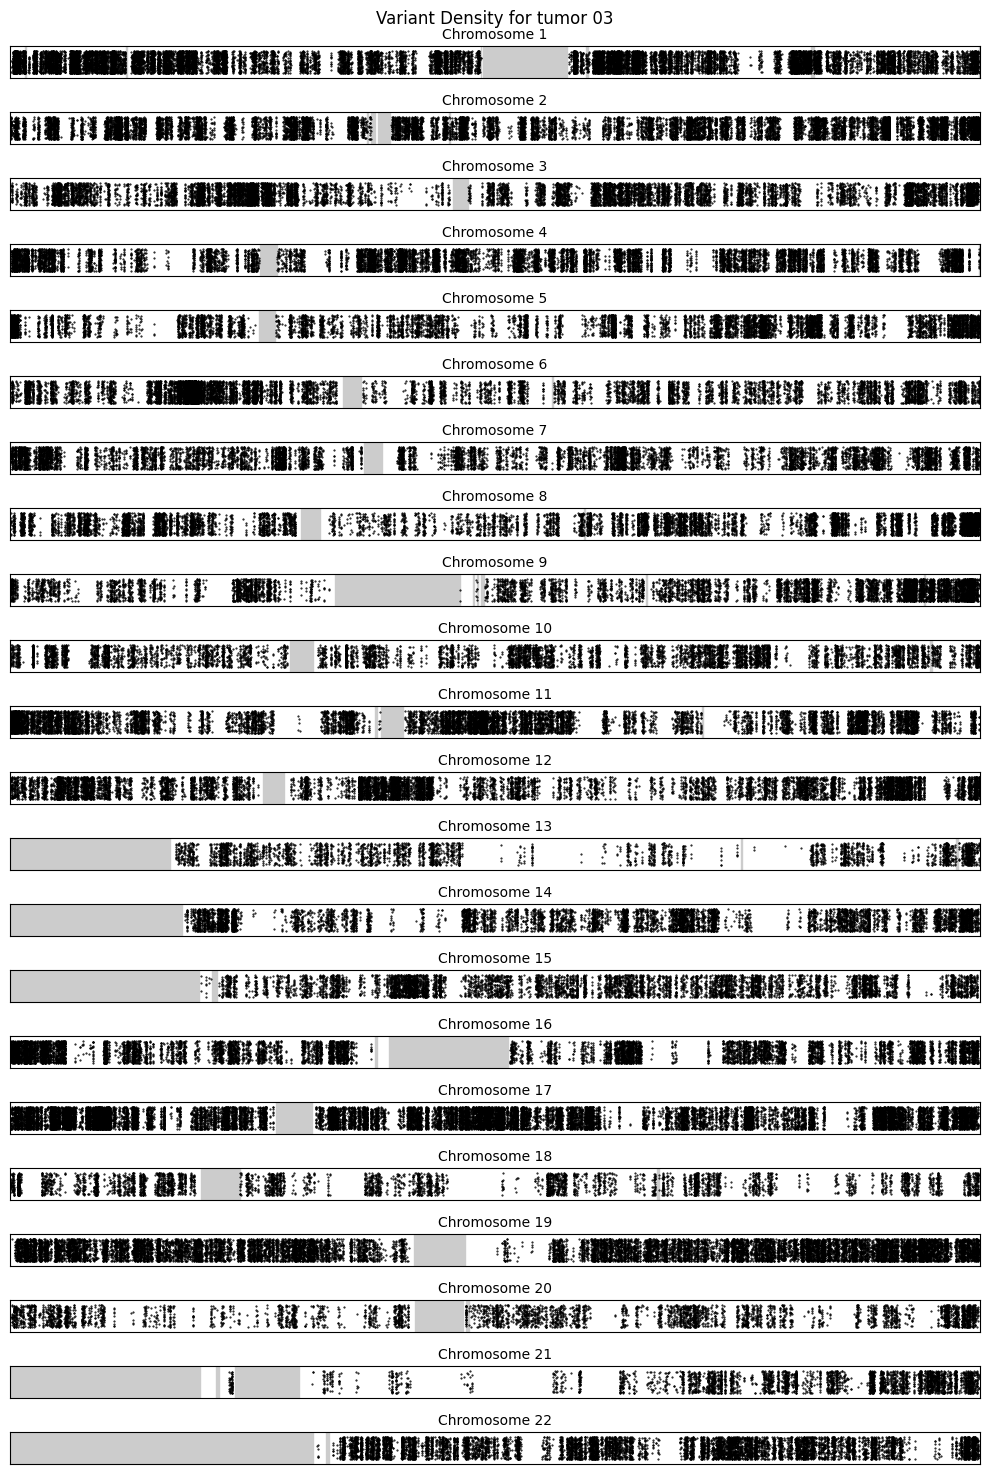

In [ ]:
exome_tumor_3 = SmallVariantsFrame.from_csv("../Julia_SVF/All_Results/tumor_01_01_DP3_exome.csv")

exome_tumor_3["chrom"] = exome_tumor_3.index

fig, axes = plt.subplots(nrows=22, ncols=1, figsize=(10, 15))

variant_density(
    exome_tumor_3, 
    axs=axes,  
    title="Variant Density for tumor 03"
)

plt.tight_layout() 
plt.savefig("./figures/supplementary/S1_variant_density_tumor_03.pdf")
plt.show()

suppl figure 2

In [ ]:
from PIL import Image, ImageDraw, ImageFont

folder_path = "../provided_data"
output_path = os.path.join( "./figures/supplementary/S3_combined_aceseq_tcn_3x2.pdf")

files = [f for f in os.listdir(folder_path) if f.endswith('_tcn.png')]
files.sort()

labeled_images = []
for f in files:
    img_path = os.path.join(folder_path, f)
    img = Image.open(img_path)
    # Extrahiert den Namen (z.B. tumor-01-01)
    label = f.replace('OE0290-PED_2LB-053_', '').replace('_tcn.png', '').upper()
    labeled_images.append((img, label))

cols = 3
rows = 2
w, h = labeled_images[0][0].size
label_height = 100
row_height = h + label_height

grid_img = Image.new('RGB', (cols * w, rows * row_height), (255, 255, 255))
draw = ImageDraw.Draw(grid_img)

try:
    font = ImageFont.truetype("arial.ttf", 45)
except:
    font = ImageFont.load_default()

for i, (img, label) in enumerate(labeled_images):
    column = i % cols
    row = i // cols
    
    x = column * w
    y = row * row_height
    
    grid_img.paste(img, (x, y + label_height))
    
    draw.text((x + 40, y + 30), label, fill=(31, 73, 125), font=font)

grid_img.save(output_path)
print(f"Das 3x2 Bild wurde hier gespeichert: {output_path}")

Das 3x2 Bild wurde hier gespeichert: ./figures/supplementary/S3_combined_aceseq_tcn_3x2.pdf
